<a href="https://colab.research.google.com/github/divyam1464/Transformer-Model/blob/main/Transformer_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

text_file = tf.keras.utils.get_file(
    fname="fra-eng.zip",
    origin="https://storage.googleapis.com/download.tensorflow.org/data/fra-eng.zip",
    extract=False
)
print(text_file)

3423204/3423204 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
/root/.keras/datasets/fra-eng.zip


In [2]:
import zipfile, os

with zipfile.ZipFile(text_file, "r") as z:
    z.extractall(os.path.dirname(text_file))

In [3]:
from pathlib import Path
import random

text_file = Path(text_file).parent / "fra.txt"

with open(text_file, encoding="utf-8") as f:
    text_pairs = f.readlines()

for _ in range(5):
    print(random.choice(text_pairs))

I hope this seat is not occupied.	J'espère que ce siège n'est pas occupé.

He's in big trouble.	Il a de gros problèmes.

She sympathized with those unfortunate people.	Elle a éprouvé de la compassion pour ces malheureux.

He's about to leave.	Il est sur le point de partir.

Tom was very happy when his team won.	Tom était très heureux lorsque son équipe a gagné.



In [4]:
import unicodedata, re

def normalize(line):
  line = unicodedata.normalize("NFKC",line.strip().lower())
  line = re.sub(r"^([^\w])(?!\s)",r"\1",line)
  line = re.sub(r"(\s[^\w])(?!\s)",r"\1",line)
  line = re.sub(r"(?!\s)([^\w])$",r"\1",line)
  line = re.sub(r"(?!\s)([^\w]\s)",r"\1",line)
  eng, fre = line.split("\t")
  fre = '[start]' + fre + '[end]'
  return eng, fre

In [5]:
with open(text_file) as fp :
  test_pairs = [normalize(line) for line in fp]

In [6]:
for _ in range(5):
  print(random.choice(test_pairs))

('i know tom has gone.', '[start]je sais que tom est parti.[end]')
("who's replacing you?", '[start]qui vous remplace ?[end]')
("a guard's been killed.", '[start]un garde a été tué.[end]')
('some of us hate it.', "[start]certains d'entre nous le détestent.[end]")
('a coke, please.', "[start]un coca s'il vous plaît.[end]")


In [7]:
eng_tokens, fre_tokens = set(), set()
eng_maxlen, fre_maxlen = 0, 0
for eng, fre in test_pairs:
  eng_token, fre_token = eng.split(), fre.split()
  eng_maxlen = max(eng_maxlen, len(eng_token))
  fre_maxlen = max(fre_maxlen, len(fre_token))
  eng_tokens.update(eng_token)
  fre_tokens.update(fre_token)

print(f"Total token in english is : {len(eng_tokens)}")
print(f"Total token in french is : {len(fre_tokens)}")
print(f"Maximum length of line is : {eng_maxlen}")
print(f"Maximum length of line is : {fre_maxlen}")

Total token in english is : 25365
Total token in french is : 44581
Maximum length of line is : 47
Maximum length of line is : 54


In [8]:
import pickle
with open("test_pairs.pickle","wb") as fp:
  pickle.dump(test_pairs,fp)

In [9]:
# embedding layer
# positional encoding
# attention model

In [10]:
from tensorflow.keras.layers import TextVectorization
import pickle

with open("test_pairs.pickle",'rb') as fp:
  text_pairs = pickle.load(fp)

In [11]:
random.shuffle(text_pairs)

In [12]:
n_val = int(.15*len(text_pairs))
n_train = len(text_pairs) - 2*n_val
train_pair = text_pairs[:n_train]
test_pair = text_pairs[n_train: n_train + n_val]

In [13]:
vacab_en = 10000
vocab_fr = 20000
seq_len = 25

In [14]:
eng_vec = TextVectorization(
    max_tokens=vacab_en,
    standardize = None,
    split = 'whitespace',
    output_mode = 'int',
    output_sequence_length = seq_len
)

In [15]:
fr_vec = TextVectorization(
    max_tokens=vocab_fr,
    standardize = None,
    split = 'whitespace',
    output_mode = 'int',
    output_sequence_length = seq_len +1
)

In [16]:
train_eng = [pair[0] for pair in train_pair]
train_fr = [pair[1] for pair in train_pair]

In [17]:
# eng_vec.adapt(train_eng)
# fr_vec.adapt(train_fr)
train_eng = [x for x, _ in train_pair]
train_fr  = [y for _, y in train_pair]

In [18]:
eng_vec.adapt(train_eng)
fr_vec.adapt(train_fr)

In [19]:
print(len(eng_vec.get_vocabulary()))
print(len(fr_vec.get_vocabulary()))
eng_vec.adapt(train_eng)
fr_vec.adapt(train_fr)

10000
20000


In [20]:
with open('vectorization.pickle', 'wb') as fp:
  data = {'train': train_pair,
          'test': test_pair,
          'eng_vec': eng_vec.get_config(),
          'fr_vec': fr_vec.get_config(),
          'eng_weights':eng_vec.get_weights(),
          'fr_weights':fr_vec.get_weights()
          }
  pickle.dump(data, fp)

In [21]:
with open('vectorization.pickle', 'rb') as fp:
  data = pickle.load(fp)

In [22]:
train_pair = data['train']
test_pair = data['test']

eng_vec = TextVectorization.from_config(data['eng_vec'])
fr_vec = TextVectorization.from_config(data['fr_vec'])

eng_vec.set_weights(data['eng_weights'])
fr_vec.set_weights(data['fr_weights'])

# Re-adapt the vectorization layers to ensure internal lookup tables are initialized
# The train_eng and train_fr lists are already available from previous cells.
eng_vec.adapt(train_eng)
fr_vec.adapt(train_fr)

In [23]:
def format_dataset(eng, fr):
  eng = eng_vec(eng)
  fr = fr_vec(fr)
  source = {
            'encoder_inputs': eng,
            'decoder_inputs': fr[:,:-1]
            }
  target = fr[:,1:]
  return (source, target)

def make_dataset(pairs, batchsize = 64):
  eng_text, fr_text = zip(*pairs)
  dataset = tf.data.Dataset.from_tensor_slices((list(eng_text), list(fr_text)))
  return dataset.shuffle(2048).batch(batchsize).map(format_dataset).prefetch(16).cache()


In [24]:
eng_vec.adapt(train_eng)
fr_vec.adapt(train_fr)
train_ds = make_dataset(train_pair)
for inputs, target in train_ds.take(1):
    print(inputs["encoder_inputs"].shape)
    print(inputs["decoder_inputs"].shape)
    print(target.shape)

(64, 25)
(64, 25)
(64, 25)


In [25]:
train_ds = make_dataset(train_pair)

In [26]:
for inputs, target in train_ds.take(1):
  print(inputs["encoder_inputs"].shape)
  print(inputs["encoder_inputs"][0])
  print(inputs["decoder_inputs"].shape)
  print(inputs["decoder_inputs"][0])
  print(target.shape)
  print(target[0])

(64, 25)
tf.Tensor(
[   2   95 3161   33   63  119  390    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0], shape=(25,), dtype=int64)
(64, 25)
tf.Tensor(
[  24   45   87 2430  835  414    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0], shape=(25,), dtype=int64)
(64, 25)
tf.Tensor(
[  45   87 2430  835  414    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0], shape=(25,), dtype=int64)


In [27]:
test_ds = make_dataset(test_pair)

***Positional Encoding***

In [28]:
import numpy as np
import tensorflow as tf
def pos_enc_matrix(L, d, n = 10000):
  assert d%2 == 0
  d2 = d//2
  P = np.zeros((L,d))
  k = np.arange(L).reshape(-1,1)
  i = np.arange(d2).reshape(1,-1)

  denom = np.power(n,-i/d2)
  args = k * denom
  P[:, :: 2] = np.sin(args)
  P[:, 1::2] = np.cos(args)
  return P

In [29]:
class PositionalEmbedding(tf.keras.layers.Layer):
  def __init__ (self, seq_len, vocab_size, embed_dim, **kwargs):
    super().__init__(**kwargs)
    self.seq_len = seq_len
    self.vocab_size = vocab_size
    self.embed_dim = embed_dim

    self.token_embeddings = tf.keras.layers.Embedding(input_dim = vocab_size, output_dim = embed_dim, mask_zero = True)
    matrix = pos_enc_matrix(seq_len, embed_dim)
    self.positional_embedding = tf.constant(matrix, dtype = 'float32')

  def call(self, inputs):
    embedded_tokens = self.token_embeddings(inputs)
    return embedded_tokens + self.positional_embedding

  def compute_mask(self, *args, **kwargs):
    return self.token_embeddings.compute_mask(*args, **kwargs)

  def get_config(self):
    config = super().get_config()
    config.update({
        'seq_len': self.seq_len,
        'vocab_size': self.vocab_size,
        'embed_dim': self.embed_dim
    })

In [30]:
vocab_en = 10000
seq_length = 25

In [31]:
for inputs, target in train_ds.take(1):
  print(inputs['encoder_inputs'])
  embed_en = PositionalEmbedding(seq_length, vocab_en, embed_dim = 512)

  en_emb = embed_en(inputs['encoder_inputs'])
  print(en_emb.shape)
  print(en_emb._keras_mask)

tf.Tensor(
[[1261    3  155 ...    0    0    0]
 [   2   75    6 ...    0    0    0]
 [  53  462   53 ...    0    0    0]
 ...
 [ 102   82   10 ...    0    0    0]
 [  21    3  123 ...    0    0    0]
 [ 287   20  222 ...    0    0    0]], shape=(64, 25), dtype=int64)
(64, 25, 512)
tf.Tensor(
[[ True  True  True ... False False False]
 [ True  True  True ... False False False]
 [ True  True  True ... False False False]
 ...
 [ True  True  True ... False False False]
 [ True  True  True ... False False False]
 [ True  True  True ... False False False]], shape=(64, 25), dtype=bool)


***Creating a Neural Network***

In [32]:
def self_attention(input_shape, prfix = 'att', mask = False, **kwargs):
  inputs = tf.keras.layers.Input(shape = input_shape, dtype = 'float32', name = f'{prfix}_in1')
  attention = tf.keras.layers.MultiHeadAttention(name = f'{prfix}_att1', **kwargs)
  norm = tf.keras.layers.LayerNormalization(name = f'{prfix}_norm1')
  add = tf.keras.layers.Add(name = f'{prfix}_add1')

  attout = attention(query = inputs, value = inputs, key = inputs, use_causal_mask = mask)
  output = norm(add([inputs, attout]))
  model = tf.keras.Model(inputs = inputs, outputs = output, name = f"{prfix}_att")
  return model


In [33]:
seq_len = 25
key_dim = 128
num_heads = 8
model = self_attention(input_shape = (seq_length, key_dim), num_heads = num_heads, key_dim = key_dim)

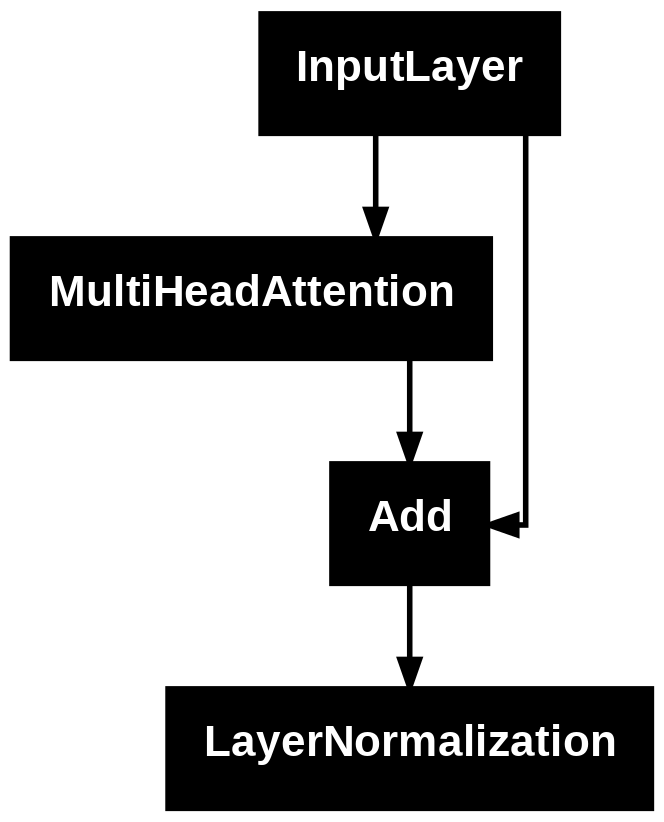

In [34]:
tf.keras.utils.plot_model(model)

***Cross attention model***

In [35]:
def cross_attention(input_shape, context_shape, prfix = 'att', **kwargs):
  context = tf.keras.layers.Input(shape = context_shape, dtype = 'float32', name = f'{prfix}_ctx')
  inputs = tf.keras.layers.Input(shape = input_shape, dtype = 'float32', name = f'{prfix}_in2')
  attention = tf.keras.layers.MultiHeadAttention(name = f'{prfix}_att2', **kwargs)
  norm = tf.keras.layers.LayerNormalization(name = f'{prfix}_norm2')
  add = tf.keras.layers.Add(name = f'{prfix}_add2')

  attout = attention(query = inputs, value = context, key = context)
  output = norm(add([inputs, attout]))

  model = tf.keras.Model(inputs = [context, inputs], outputs = output, name = f"{prfix}_crs_at")
  return model

In [36]:
model = cross_attention(input_shape = (seq_length, key_dim), context_shape = (seq_length, key_dim), num_heads = num_heads, key_dim = key_dim)


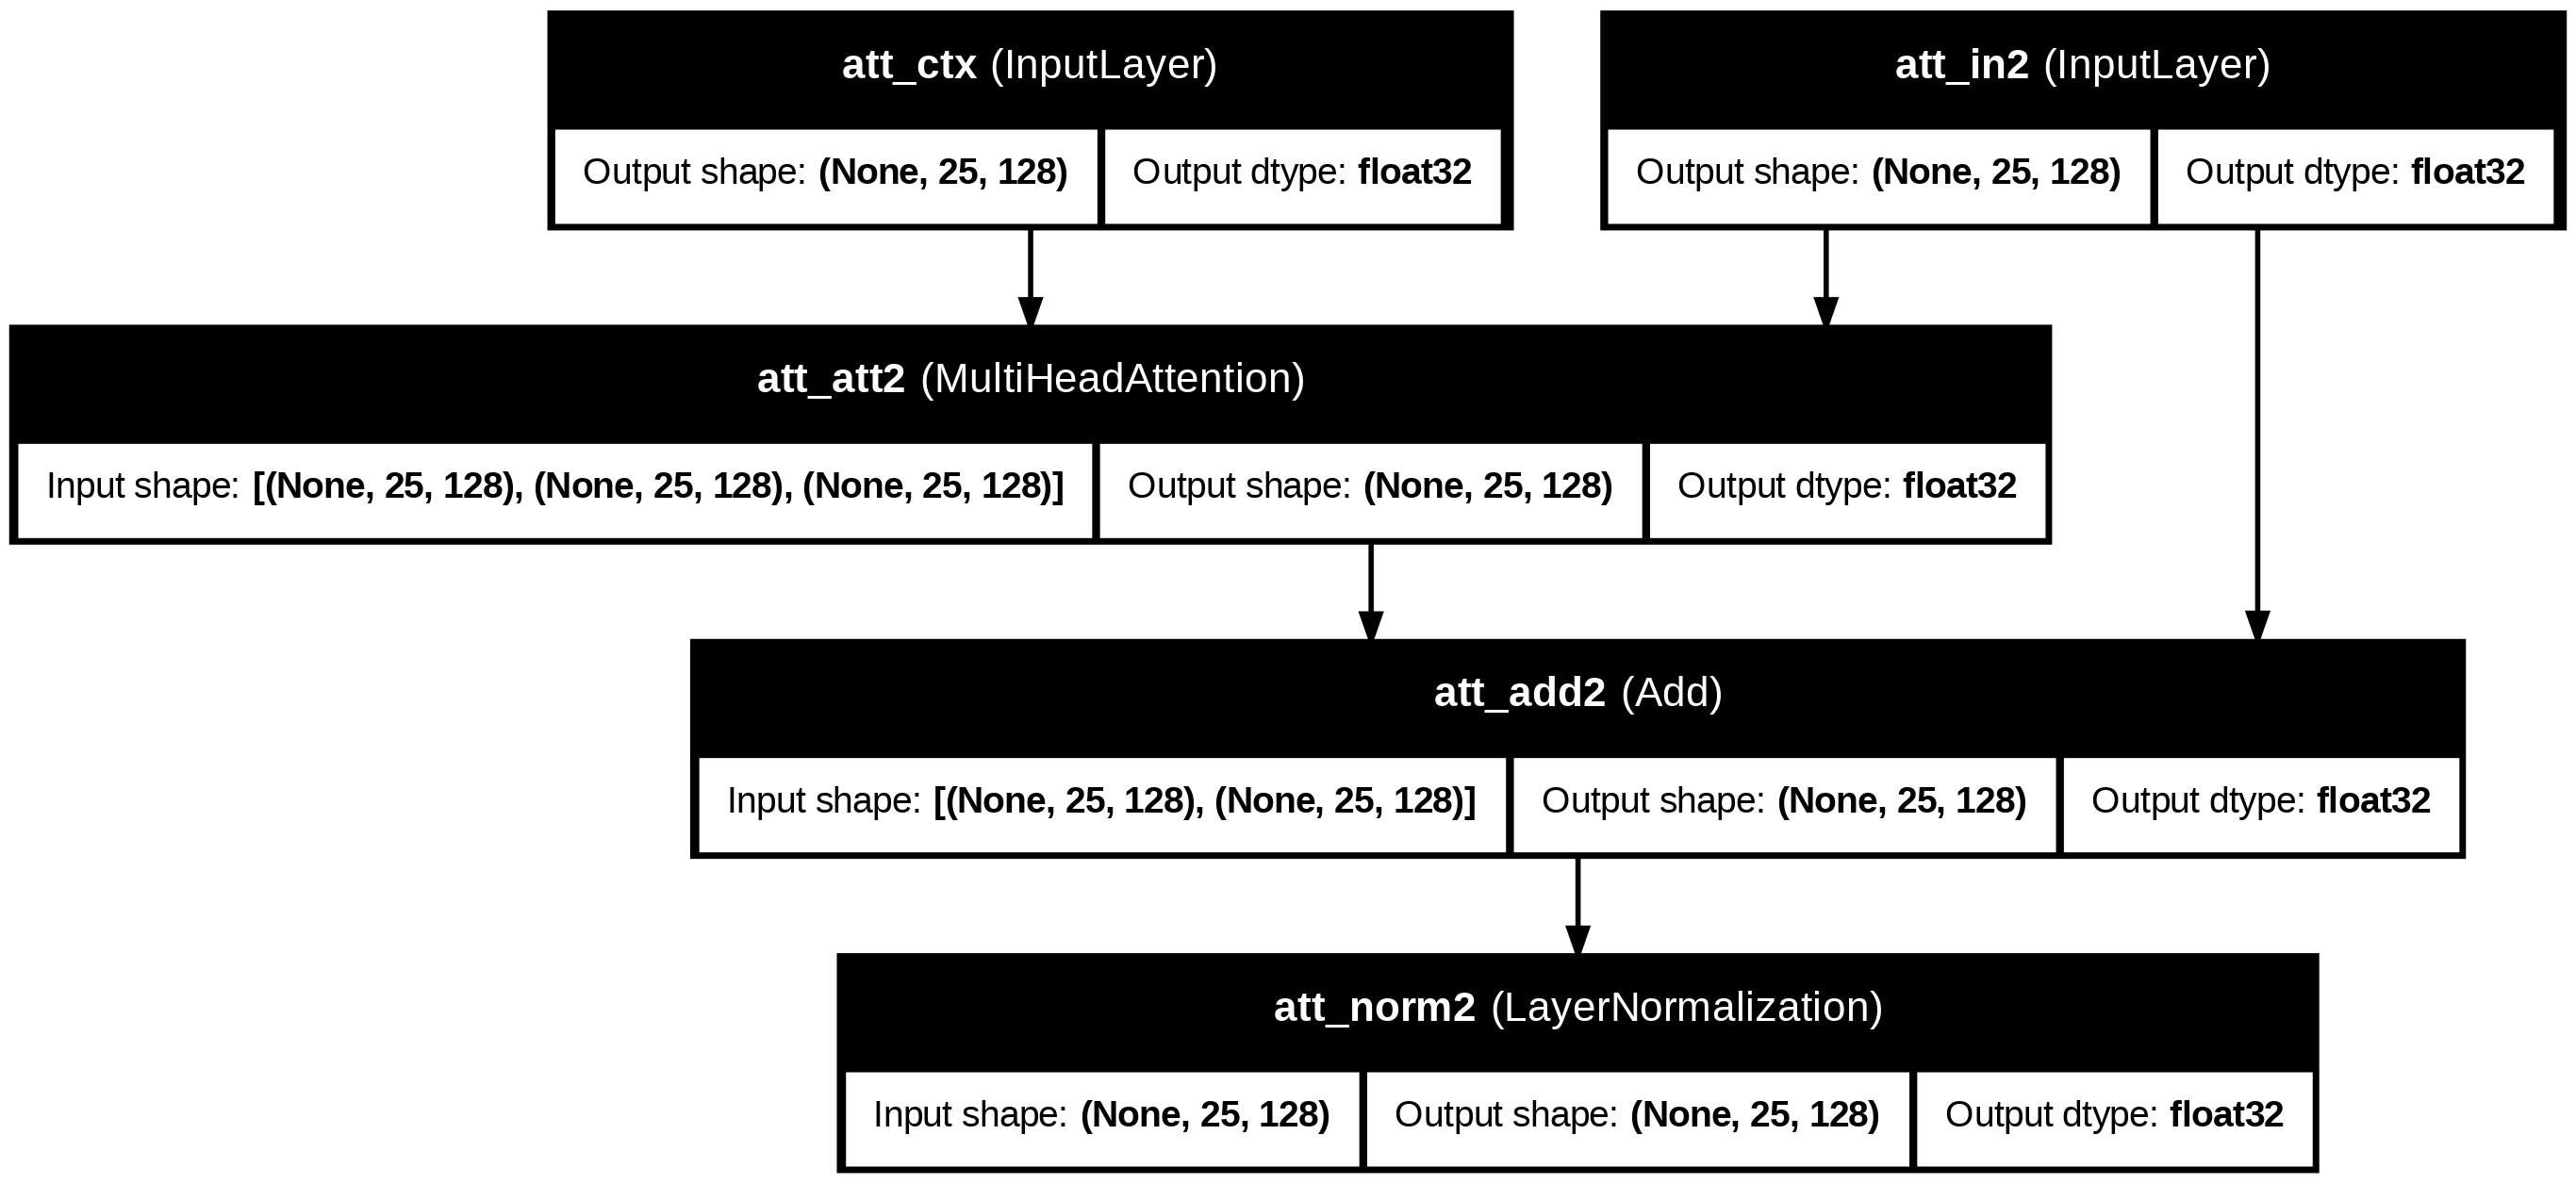

In [37]:
tf.keras.utils.plot_model(model, show_shapes = True, show_dtype = True, show_layer_names = True, show_layer_activations = True)

***Feed Forward Nerual Network***

In [38]:
def feed_forward(input_shape, model_dim, ff_dim, dropout = .1, prefix = 'ff'):
  inputs = tf.keras.layers.Input(shape = input_shape, dtype = 'float32', name = f'{prefix}_in3')
  dense1 = tf.keras.layers.Dense(ff_dim, activation = 'relu', name = f'{prefix}_ff1')
  dense2 = tf.keras.layers.Dense(model_dim, name = f'{prefix}_ff2')
  drop = tf.keras.layers.Dropout(dropout, name = f'{prefix}_drop')
  add = tf.keras.layers.Add(name = f'{prefix}_add3')

  ffout = drop(dense2(dense1(inputs)))
  norm = tf.keras.layers.LayerNormalization(name = f'{prefix}_norm3')
  output = norm(add([inputs, ffout]))

  model = tf.keras.Model(inputs = inputs, outputs = output, name = f"{prefix}_ff")
  return model

In [39]:
ff_dim = 512
model = feed_forward(input_shape = (seq_length, key_dim), model_dim = key_dim, ff_dim = ff_dim)

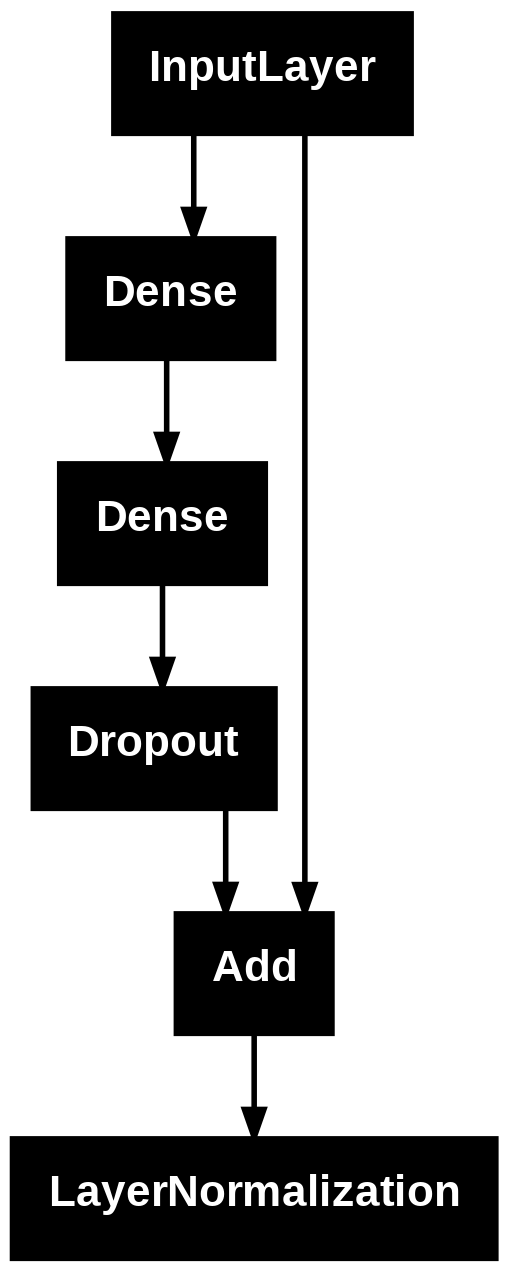

In [40]:
tf.keras.utils.plot_model(model)

***Encoder & Decoder***

In [41]:
import tensorflow as tf
def encoder(input_shape, key_dim, ff_dim, dropout = .1, prefix = 'enc', **kwargs):
  model = tf.keras.models.Sequential([
      tf.keras.layers.Input(shape = input_shape, dtype = 'float32', name = f'{prefix}_in0'),
      self_attention(input_shape = input_shape, prfix = prefix, key_dim = key_dim, mask = False, **kwargs),
      feed_forward(input_shape, key_dim, ff_dim, dropout, prefix)
  ])
  return model

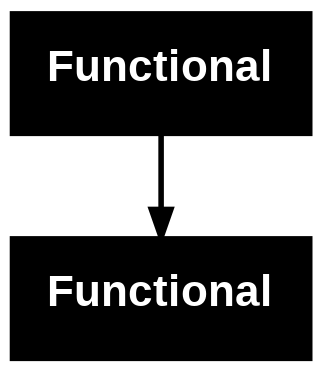

In [42]:
seq_len = 25
key_dim = 128
ff_dim = 512
num_heads = 8

model = encoder(input_shape = (seq_length, key_dim), key_dim = key_dim, ff_dim = ff_dim, num_heads = num_heads)
tf.keras.utils.plot_model(model)

In [43]:
def decoder(input_shape, key_dim, ff_dim, dropout = .1, prefix = 'dec', **kwargs):
  inputs = tf.keras.layers.Input(shape = input_shape, dtype = 'float32', name = f'{prefix}_in0')
  context = tf.keras.layers.Input(shape = input_shape, dtype = 'float32', name = f'{prefix}_ctx0')
  attmodel = self_attention(input_shape, prfix = prefix, key_dim = key_dim, mask = True, **kwargs)
  crossmodel = cross_attention(input_shape, input_shape, key_dim = key_dim, prfix = prefix, **kwargs)
  ffmodel = feed_forward(input_shape, key_dim, ff_dim, dropout, prefix)

  x = attmodel(inputs)
  x = crossmodel([context, x])
  output = ffmodel(x)
  model = (tf.keras.Model(inputs = [inputs, context], outputs = output, name = prefix))
  return model

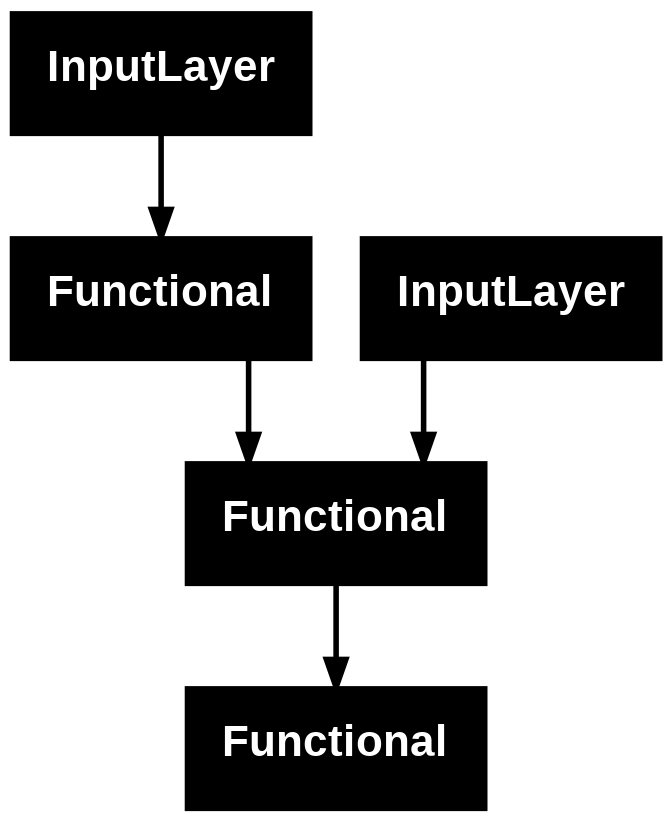

In [44]:
seq_len = 25
key_dim = 128
ff_dim = 512
num_heads = 8

model = decoder(input_shape = (seq_length, key_dim), key_dim = key_dim, ff_dim = ff_dim, num_heads = num_heads)
tf.keras.utils.plot_model(model)

In [45]:
def transformer(num_layers, num_heads, seq_len, key_dim, ff_dim, vocab_size_en, vocab_size_fr, dropout = .1, name = 'transformer'):

  input_enc = tf.keras.layers.Input(shape = (seq_len,), dtype = 'float32', name = 'encoder_inputs')
  input_dec = tf.keras.layers.Input(shape = (seq_len,), dtype = 'float32', name = 'decoder_inputs')

  emb_enc = PositionalEmbedding(seq_len, vocab_size_en, key_dim, name = 'embed_enc')
  emb_dec = PositionalEmbedding(seq_len, vocab_size_fr, key_dim, name = 'embed_dec')

  encoders = [encoder(input_shape = (seq_length, key_dim), key_dim = key_dim, ff_dim = ff_dim, dropout = dropout, prefix = f"enc{i}", num_heads = num_heads) for i in range(num_layers)]
  decoders = [decoder(input_shape = (seq_length, key_dim), key_dim = key_dim, ff_dim = ff_dim, dropout = dropout, prefix = f'dec{i}', num_heads = num_heads) for i in range(num_layers)]

  final = tf.keras.layers.Dense(vocab_size_fr, name = 'linear')

  x1 = emb_enc(input_enc)
  x2 = emb_dec(input_dec)

  for layer in encoders:
    x1 = layer(x1)
  for layer in decoders:
    x2 = layer([x2, x1])

  output = final(x2)\

  try:
    del output.keras_mask
  except:
    pass

  model = tf.keras.Model(inputs = [input_enc, input_dec], outputs = output, name = name)
  return model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'sequential_1' (of type Sequential) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'dec0' (of type Functional) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


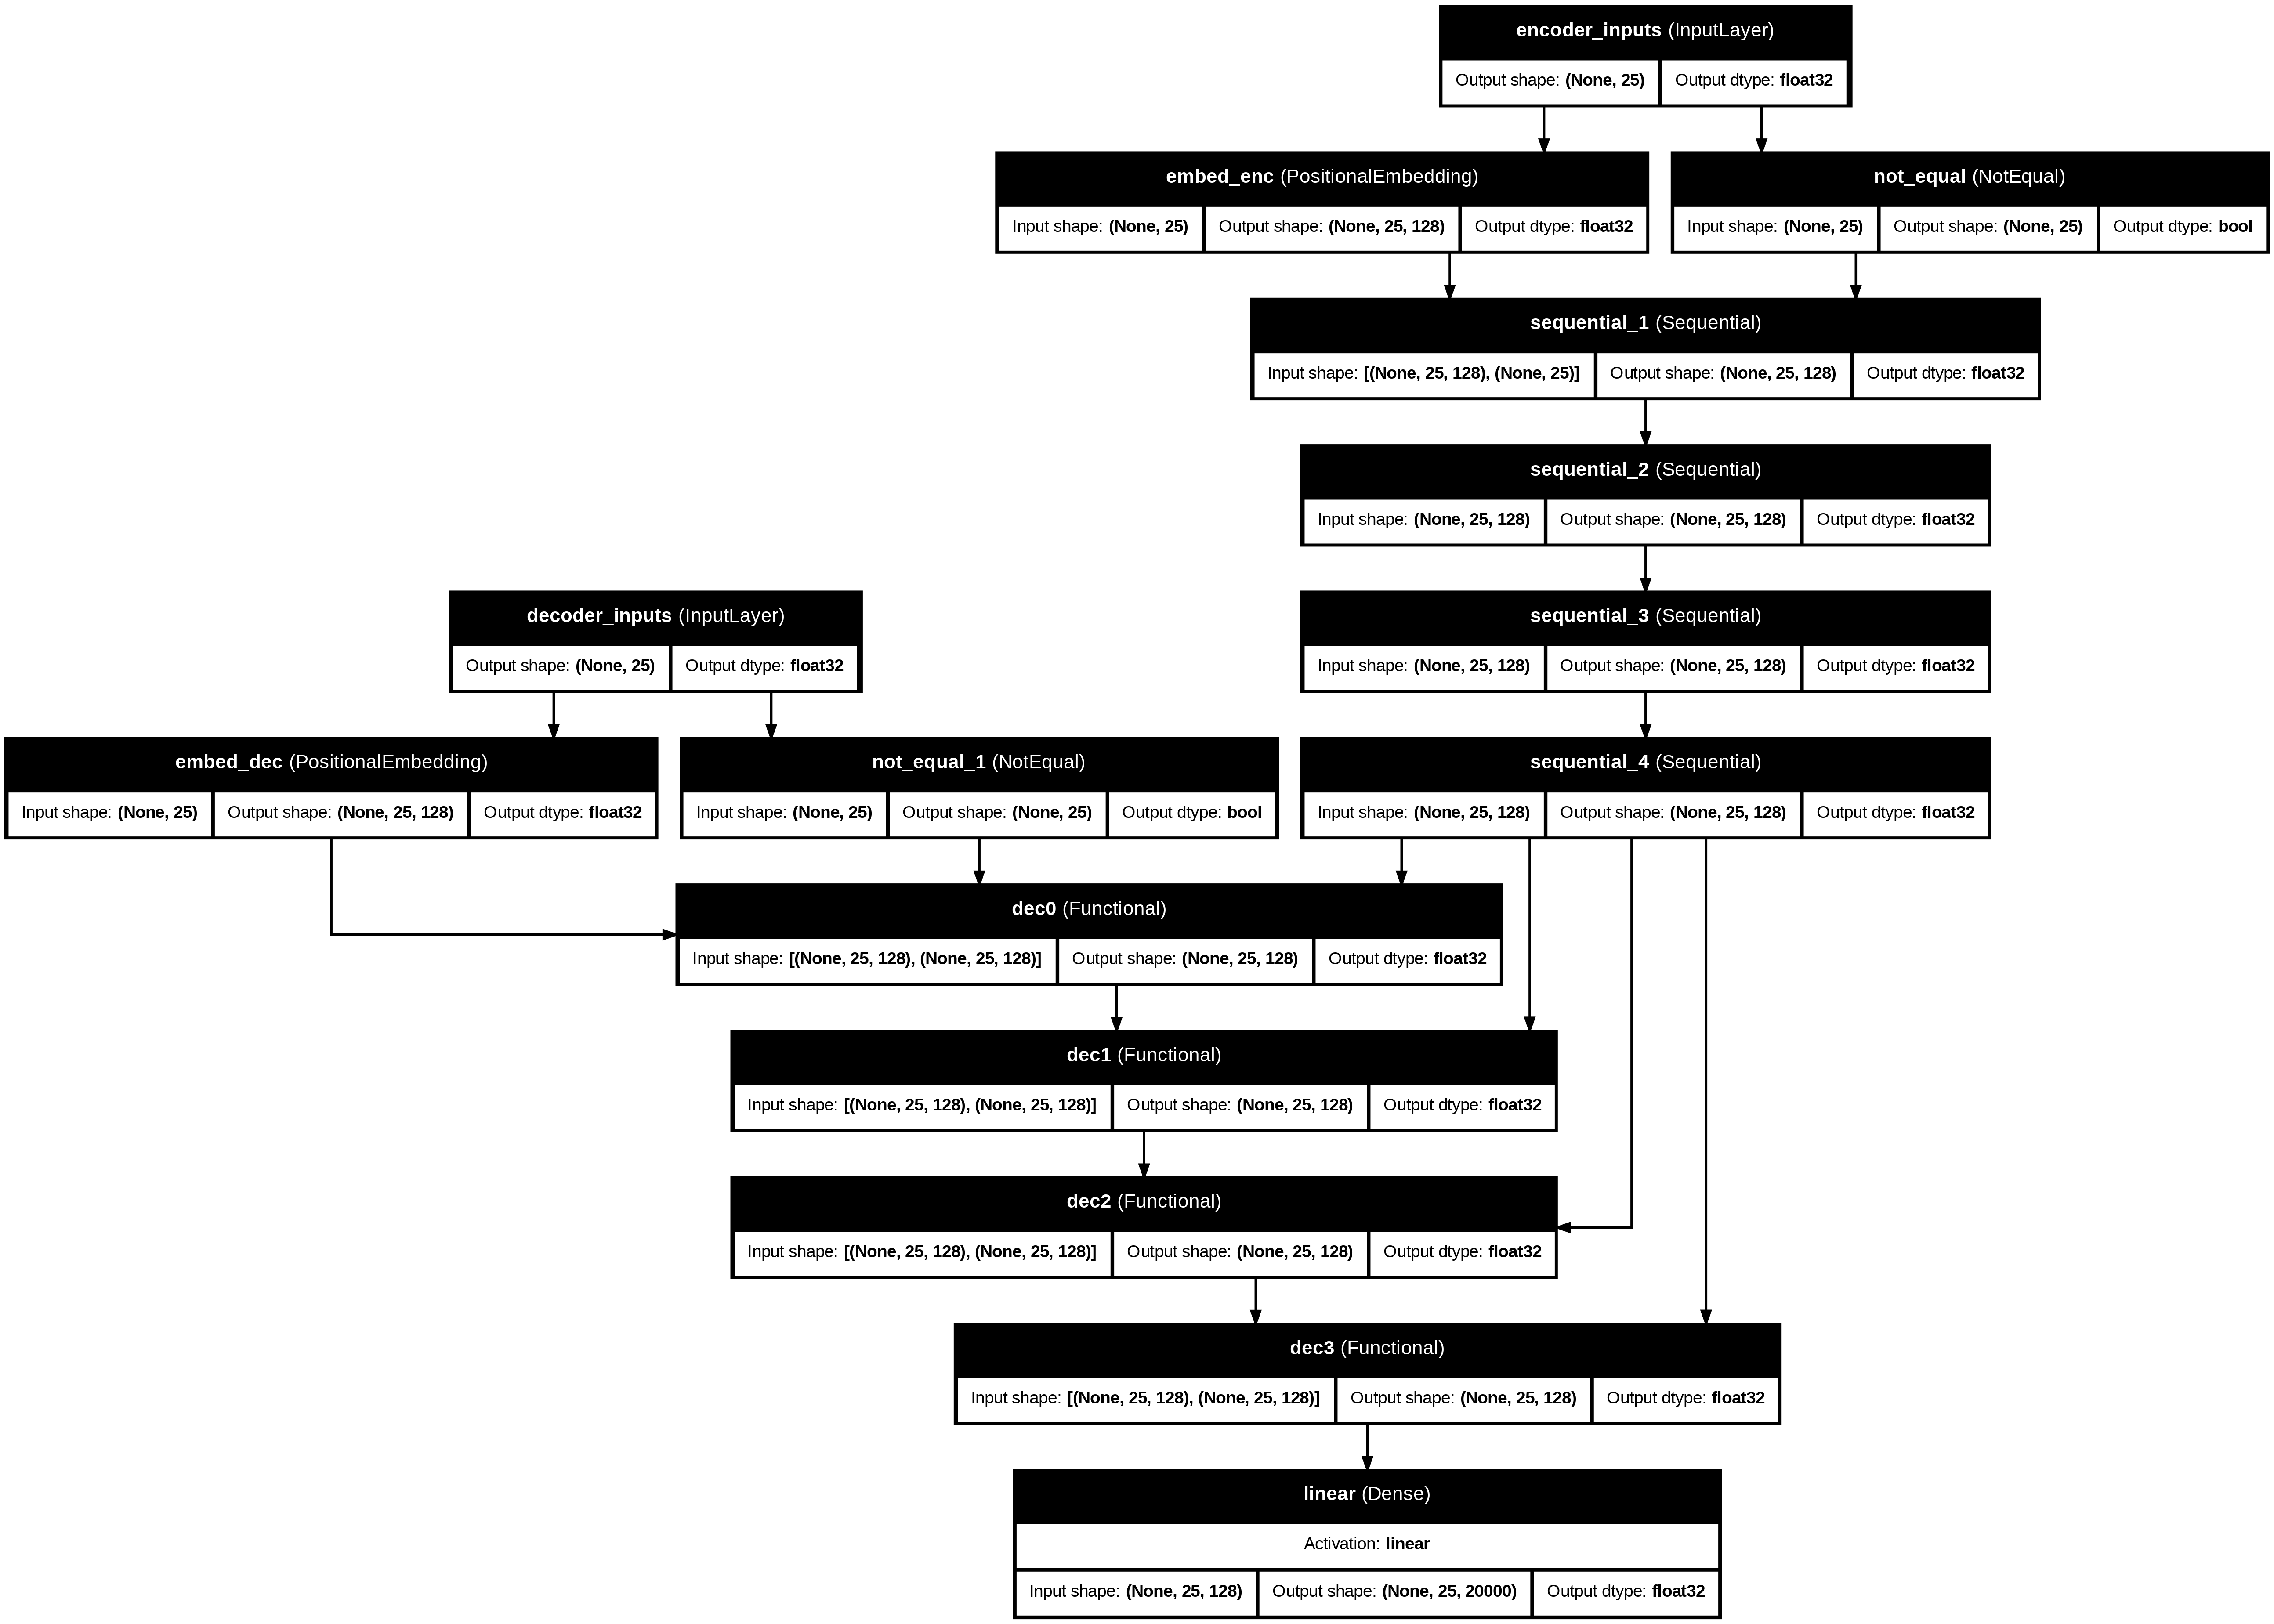

In [46]:
seq_len = 25
num_layers = 4
num_heads = 8
key_dim = 128
ff_dim = 512
dropout = .1
vocab_size_en = 10000
vocab_size_fr = 20000

model = transformer(num_layers, num_heads, seq_len, key_dim, ff_dim, vocab_size_en, vocab_size_fr, dropout)

tf.keras.utils.plot_model(model, show_shapes = True, show_dtype = True, show_layer_names = True, show_layer_activations = True)

In [47]:
model.compile(loss = 'sparse_categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])
model.summary()

Model: "transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 25)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed_enc           │ (None, 25, 128)   │  1,280,000 │ encoder_inputs[0… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 25)        │          0 │ encoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 25, 128)   │    659,712 │ embed_enc[0][0],  │
│ (Sequential)        │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 25, 128)   │    659,712 │ sequential_1[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 25)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 25, 128)   │    659,712 │ sequential_2[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed_dec           │ (None, 25, 128)   │  2,560,000 │ decoder_inputs[0… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_4        │ (None, 25, 128)   │    659,712 │ sequential_3[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 25)        │          0 │ decoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec0 (Functional)   │ (None, 25, 128)   │  1,187,456 │ embed_dec[0][0],  │
│                     │                   │            │ sequential_4[0][… │
│                     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec1 (Functional)   │ (None, 25, 128)   │  1,187,456 │ dec0[0][0],       │
│                     │                   │            │ sequential_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec2 (Functional)   │ (None, 25, 128)   │  1,187,456 │ dec1[0][0],       │
│                     │                   │            │ sequential_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec3 (Functional)   │ (None, 25, 128)   │  1,187,456 │ dec2[0][0],       │
│                     │                   │            │ sequential_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ linear (Dense)      │ (None, 25, 20000) │  2,580,000 │ dec3[0][0]        │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,808,672 (52.68 MB)

 Trainable params: 13,808,672 (52.68 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(train_ds, epochs = 20, validation_data = test_ds)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'enc0_att' (of type Functional) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'sequential_1' (of type Sequential) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'dec0_att' (of type Functional) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist

1828/1828 ━━━━━━━━━━━━━━━━━━━━ 12202s 7s/step - accuracy: 0.7693 - loss: 3.7745 - val_accuracy: 0.7726 - val_loss: 3.6666
Epoch 2/20
1828/1828 ━━━━━━━━━━━━━━━━━━━━ 12183s 7s/step - accuracy: 0.7727 - loss: 3.6661 - val_accuracy: 0.7726 - val_loss: 3.6666
Epoch 3/20
1828/1828 ━━━━━━━━━━━━━━━━━━━━ 12327s 7s/step - accuracy: 0.7727 - loss: 3.6661 - val_accuracy: 0.7726 - val_loss: 3.6666
Epoch 4/20
1027/1828 ━━━━━━━━━━━━━━━━━━━━ 1:23:58 6s/step - accuracy: 0.7729 - loss: 3.6624

In [ ]:
class customSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):

  def __init__(self, key_dim, warmup_steps = 40000):
    super().__init__()
    self.key_dim = key_dim
    self.warmup_steps = warmup_steps

    self.d = tf.cast(self.key_dim, tf.float32)

  def __call__(self, step):
      step = tf.cast(step, tf.float32)
      arg1 = tf.math.rsqrt(step)
      arg2 = step * (self.warmup_steps ** -1.5)
      return tf.math.rsqrt(self.d) * tf.math.minimum(arg1, arg2)

  def get_config(self):
      config ={
          'key_dim': self.key_dim,
          'warmup_steps' : self.warmup_steps
      }
      return config


key_dim = 128
lr = customSchedule(key_dim)
optimizer = tf.keras.optimizers.Adam(lr, beta_1 = .9, beta_2 = .98, epsilon = 1e-9)

In [ ]:
def masked_loss(label, pred):
  mask = label != 0
  loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True, reduction = 'none')
  loss = loss_object(label, pred)

  mask = tf.cast(mask, dtype = loss.dtype)
  loss *= mask

  loss = tf.reduce_sum(loss)/tf.reduce_sum(mask)
  return loss


def mask_accuracy(label, pred):
  pred = tf.argmax(pred, axis = 2)
  label = tf.cast(label, pred.dtype)
  match = label == pred

  mask = label != 0
  match = match & mask

  match = tf.cast(match, dtype = tf.float32)
  mask = tf.cast(mask, dtype = tf.float32)
  return tf.reduce_sum(match)/tf.reduce_sum(mask)

In [ ]:
model.compile(loss = masked_loss, optimizer = optimizer, metrics = [mask_accuracy])
model.summary()

In [ ]:
history = model.fit(train_ds, epochs = 20, validation_data = test_ds)

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,figsize = (6,8), sharex = True)
fig.suptitle(
    "training history"
)
x = list(range(1,21))
axes[0].plot(x.history.hostory['loss'], alpha = .5, lable = 'loss')
axes[0].plot(x.history.history['val_loss'], alpha = .5, label = 'val_loss')
axes[0].set_ylabel('Loss')
axes[0].legend(loc = 'upper')
axes[1].plot(x.history.history['mask_accuracy'], alpha = .5, label = 'mask_accuracy')
axes[1].plot(x.history.history['val_mask_accuracy'], alpha = .5, label = 'val_mask_accuracy')
axes[1].set_ylabel('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend(loc = 'lower right')
plt.show()

In [ ]:
def translate(sentence):
  enc_tokens = eng_vec([sentence])
  lookup = list(fr_vec.get_vocabulary())
  start_sent , end_sent = '[start]', '[end]'
  output_sent = [start_sent]
  for i in range(seq_len):
    vector = fr_vec([''.join(output_sent)])
    assert vector.shape == (1, seq_len + 1)
    dec_tokens = vector[:, :-1]
    assert dec_tokens.shape == (1, seq_len)
    pred = model([enc_tokens, dec_tokens])
    assert pred.shape == (1, seq_len, vocab_size_fr)
    word = lookup[np.argmax(pred[0, i, :])]
    output_sent.append(word)
    if word == end_sent:
      break
  return output_sent

In [ ]:
seq_len = 25
vocab_size_en = 10000
vocab-size_fr = 20000
test_count = 20

for n in range(test_count):
  eng_sent, fre_sent = random.choice(test_pair)
  translate = translate(eng_sent)

  print(f"Test Case: {n}")
  print(f"English Sentence : {eng_sent}")
  print(f"Translated Value : {' '.join(tran)}")
  print(f"French Sentence : {fre_sent}")